In [1]:
!pip install -q kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:34<00:00, 84.6MB/s]



In [4]:
!ls -lh /content

total 2.7G
-rw-r--r-- 1 root root   72 Oct  7 13:54 kaggle.json
-rw-r--r-- 1 root root 2.7G Oct 12  2019 new-plant-diseases-dataset.zip
drwxr-xr-x 1 root root 4.0K Sep 30 13:28 sample_data


In [5]:
!mkdir -p /content/plant_dataset
!unzip -q /content/new-plant-diseases-dataset.zip -d /content/plant_dataset

In [6]:
!find /content/plant_dataset -maxdepth 3 -type d | head -50

/content/plant_dataset
/content/plant_dataset/test
/content/plant_dataset/test/test
/content/plant_dataset/new plant diseases dataset(augmented)
/content/plant_dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)
/content/plant_dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
/content/plant_dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid
/content/plant_dataset/New Plant Diseases Dataset(Augmented)
/content/plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
/content/plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
/content/plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [7]:
import tensorflow as tf

train_path = "/content/plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_path = "/content/plant_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [8]:
print(train_dataset.class_names)
print("Number of classes:", len(train_dataset.class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [9]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (32, 128, 128, 3)
Label shape: (32,)


In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

Found 70295 images belonging to 38 classes.


In [14]:
for x, y in training_set:
  print(x,x.shape)
  print(y,y.shape)
  break

[[[[0.5921569  0.6        0.6901961 ]
   [0.5921569  0.6        0.6901961 ]
   [0.5921569  0.6        0.6901961 ]
   ...
   [0.45098042 0.454902   0.5254902 ]
   [0.45098042 0.454902   0.5254902 ]
   [0.45098042 0.454902   0.5254902 ]]

  [[0.5921569  0.6        0.6901961 ]
   [0.5921569  0.6        0.6901961 ]
   [0.5921569  0.6        0.6901961 ]
   ...
   [0.45098042 0.454902   0.5254902 ]
   [0.45098042 0.454902   0.5254902 ]
   [0.45098042 0.454902   0.5254902 ]]

  [[0.5921569  0.6        0.6901961 ]
   [0.5921569  0.6        0.6901961 ]
   [0.5921569  0.6        0.6901961 ]
   ...
   [0.45098042 0.454902   0.5254902 ]
   [0.45098042 0.454902   0.5254902 ]
   [0.45098042 0.454902   0.5254902 ]]

  ...

  [[0.5882353  0.58431375 0.6392157 ]
   [0.5882353  0.58431375 0.6392157 ]
   [0.5882353  0.58431375 0.6392157 ]
   ...
   [0.5294118  0.52156866 0.57254905]
   [0.5294118  0.52156866 0.57254905]
   [0.5294118  0.52156866 0.57254905]]

  [[0.5882353  0.58431375 0.6392157 ]
   [0.5

In [15]:
#building CNN

In [16]:
cnn = tf.keras.models.Sequential()

In [17]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation = 'relu', input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation = 'relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides = 2))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation = 'relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation = 'relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides = 2))

In [19]:
cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation = 'relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation = 'relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides = 2))

In [20]:
cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3, padding='same', activation = 'relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3, activation = 'relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides = 2))

In [21]:
cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, padding='same', activation = 'relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, activation = 'relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides = 2))

In [22]:
from tensorflow.keras.layers import Dropout
cnn.add(Dropout(0.25))

In [23]:
cnn.add(tf.keras.layers.Flatten())

In [24]:
cnn.add(tf.keras.layers.Dense(units = 1500, activation='relu'))

In [25]:
cnn.add(Dropout(0.4))

In [26]:
cnn.add(tf.keras.layers.Dense(units = 38, activation='softmax'))

In [27]:
#compiling the CNN

In [28]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [29]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#training cnn model

In [31]:
training_history = cnn.fit(x = training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 478s 208ms/step - accuracy: 0.4233 - loss: 1.9600 - val_accuracy: 0.6948 - val_loss: 0.9503
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 430s 196ms/step - accuracy: 0.7550 - loss: 0.7744 - val_accuracy: 0.8215 - val_loss: 0.5548
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 422s 192ms/step - accuracy: 0.8410 - loss: 0.4924 - val_accuracy: 0.8495 - val_loss: 0.4557
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 424s 193ms/step - accuracy: 0.8828 - loss: 0.3561 - val_accuracy: 0.9067 - val_loss: 0.2738
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 427s 194ms/step - accuracy: 0.9061 - loss: 0.2831 - val_accuracy: 0.9251 - val_loss: 0.2251
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 446s 203ms/step - accuracy: 0.9238 - loss: 0.2297 - val_accuracy: 0.9232 - val_loss: 0.2307
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 442s 201ms/step - accuracy: 0.9359 - loss: 0.1907 - val_accuracy: 0.9254 - val_loss: 0.2218
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 417s 190ms/step - ac

In [32]:
#model evaluation on training set

In [33]:
train_loss, train_acc = cnn.evaluate(training_set)
print(train_loss, train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 361s 164ms/step - accuracy: 0.9689 - loss: 0.0934
0.0933893471956253 0.9688597917556763


In [34]:
val_loss, val_acc = cnn.evaluate(validation_set)
print(val_loss, val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.9678 - loss: 0.0954
0.09540402889251709 0.9678465723991394


In [35]:
cnn.save("trained_plant_model2.keras")

In [70]:
training_history.history

{'accuracy': [0.42331603169441223,
  0.7550181150436401,
  0.840998649597168,
  0.8827654719352722,
  0.9061099886894226,
  0.9238494634628296,
  0.93585604429245,
  0.944875180721283,
  0.9523437023162842,
  0.9578490853309631],
 'loss': [1.959963321685791,
  0.7743521928787231,
  0.49244144558906555,
  0.3561018705368042,
  0.28306207060813904,
  0.2297126054763794,
  0.19067202508449554,
  0.1633606106042862,
  0.1426232010126114,
  0.12564828991889954],
 'val_accuracy': [0.6947985291481018,
  0.821534276008606,
  0.8494764566421509,
  0.9066696763038635,
  0.925051212310791,
  0.9231732487678528,
  0.9253926873207092,
  0.9505463242530823,
  0.9169701933860779,
  0.9678465723991394],
 'val_loss': [0.9503008127212524,
  0.5548178553581238,
  0.45574280619621277,
  0.27384161949157715,
  0.2250659465789795,
  0.23070257902145386,
  0.22177843749523163,
  0.14833444356918335,
  0.2581219971179962,
  0.09540402889251709]}

In [71]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

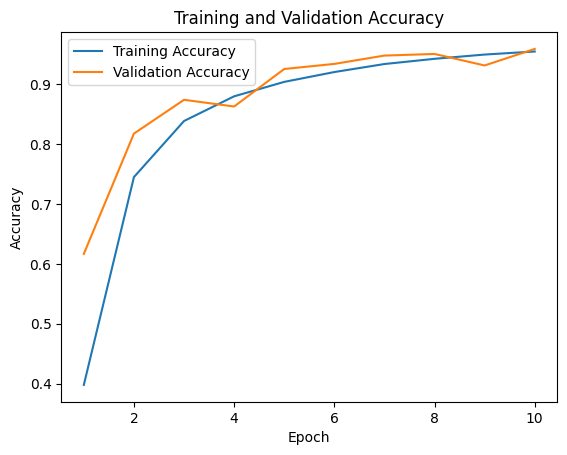

In [72]:
#accuracy visualization
epochs = range(1, 11)

accuracy = [0.3979, 0.7447, 0.8383, 0.8795, 0.9036,
            0.9200, 0.9334, 0.9421, 0.9492, 0.9543]

val_accuracy = [0.6166, 0.8173, 0.8737, 0.8625, 0.9251,
                0.9336, 0.9475, 0.9502, 0.9310, 0.9586]

plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

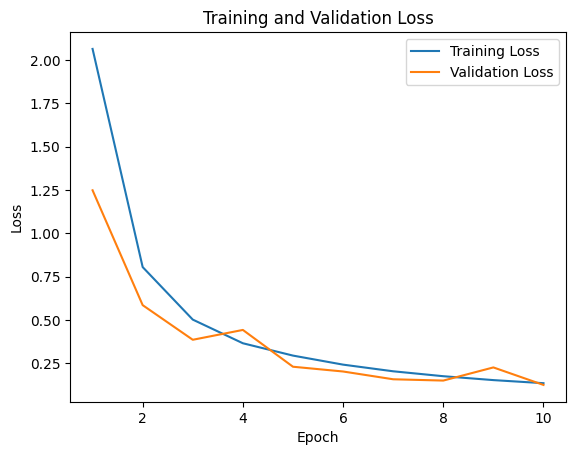

In [73]:
#loss visualization
loss = [2.0641, 0.8048, 0.5016, 0.3651, 0.2939,
        0.2417, 0.2033, 0.1749, 0.1524, 0.1346]

val_loss = [1.2481, 0.5851, 0.3852, 0.4420, 0.2296,
            0.2021, 0.1572, 0.1497, 0.2256, 0.1246]

plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [85]:
class_name = list(validation_set.class_indices.keys())

print(class_name)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [75]:
#other metrices for model evaluation

In [76]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'plant_dataset', 'trained_plant_model2.keras', 'new-plant-diseases-dataset.zip', 'training_hist.json', 'kaggle.json', 'sample_data']


In [77]:
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

test_set = validation_datagen.flow_from_directory(
    valid_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 17572 images belonging to 38 classes.


In [78]:
y_pred = cnn.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step


(array([[9.9999917e-01, 4.5023651e-09, 7.4399195e-11, ..., 2.9351550e-19,
         1.7481426e-13, 1.8438261e-14],
        [9.9999642e-01, 7.4013383e-07, 3.7214228e-08, ..., 1.6444191e-15,
         6.2441462e-11, 1.4482556e-11],
        [9.9999869e-01, 2.5568543e-09, 5.2898202e-10, ..., 4.6540945e-18,
         1.2457221e-12, 1.5062317e-12],
        ...,
        [1.2245374e-10, 3.1114445e-17, 4.2835410e-13, ..., 1.7009120e-11,
         7.9069699e-13, 9.9999833e-01],
        [1.0113877e-11, 1.1456549e-18, 5.1028280e-14, ..., 2.8874967e-11,
         9.5324099e-14, 9.9999928e-01],
        [1.9493906e-14, 6.0992789e-14, 1.4153157e-15, ..., 5.2592551e-16,
         1.2107339e-11, 9.9999774e-01]], dtype=float32),
 (17572, 38))

In [79]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [80]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [81]:
y_pred = cnn.predict(validation_set)

predicted_categories = np.argmax(y_pred, axis=1)

print(predicted_categories.shape)

550/550 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step
(17572,)


In [87]:
Y_true = test_set.classes

print(Y_true.shape)

(17572,)


In [89]:
class_name = list(test_set.class_indices.keys())

print(class_name)
print("Number of classes:", len(class_name))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [90]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    Y_true,
    predicted_categories,
    target_names=class_name
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.97      0.97       504
                                 Apple___Black_rot       0.97      0.99      0.98       497
                          Apple___Cedar_apple_rust       0.98      0.99      0.98       440
                                   Apple___healthy       0.95      0.97      0.96       502
                               Blueberry___healthy       0.96      0.94      0.95       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.97      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.88      0.91       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.94      0.97      0.

In [91]:
cm = confusion_matrix(Y_true, predicted_categories)

print(cm)

[[488   4   0 ...   0   0   0]
 [  0 490   0 ...   0   0   0]
 [  0   0 436 ...   0   0   0]
 ...
 [  0   0   0 ... 450   0   0]
 [  0   0   0 ...   0 448   0]
 [  0   0   1 ...   0   0 474]]


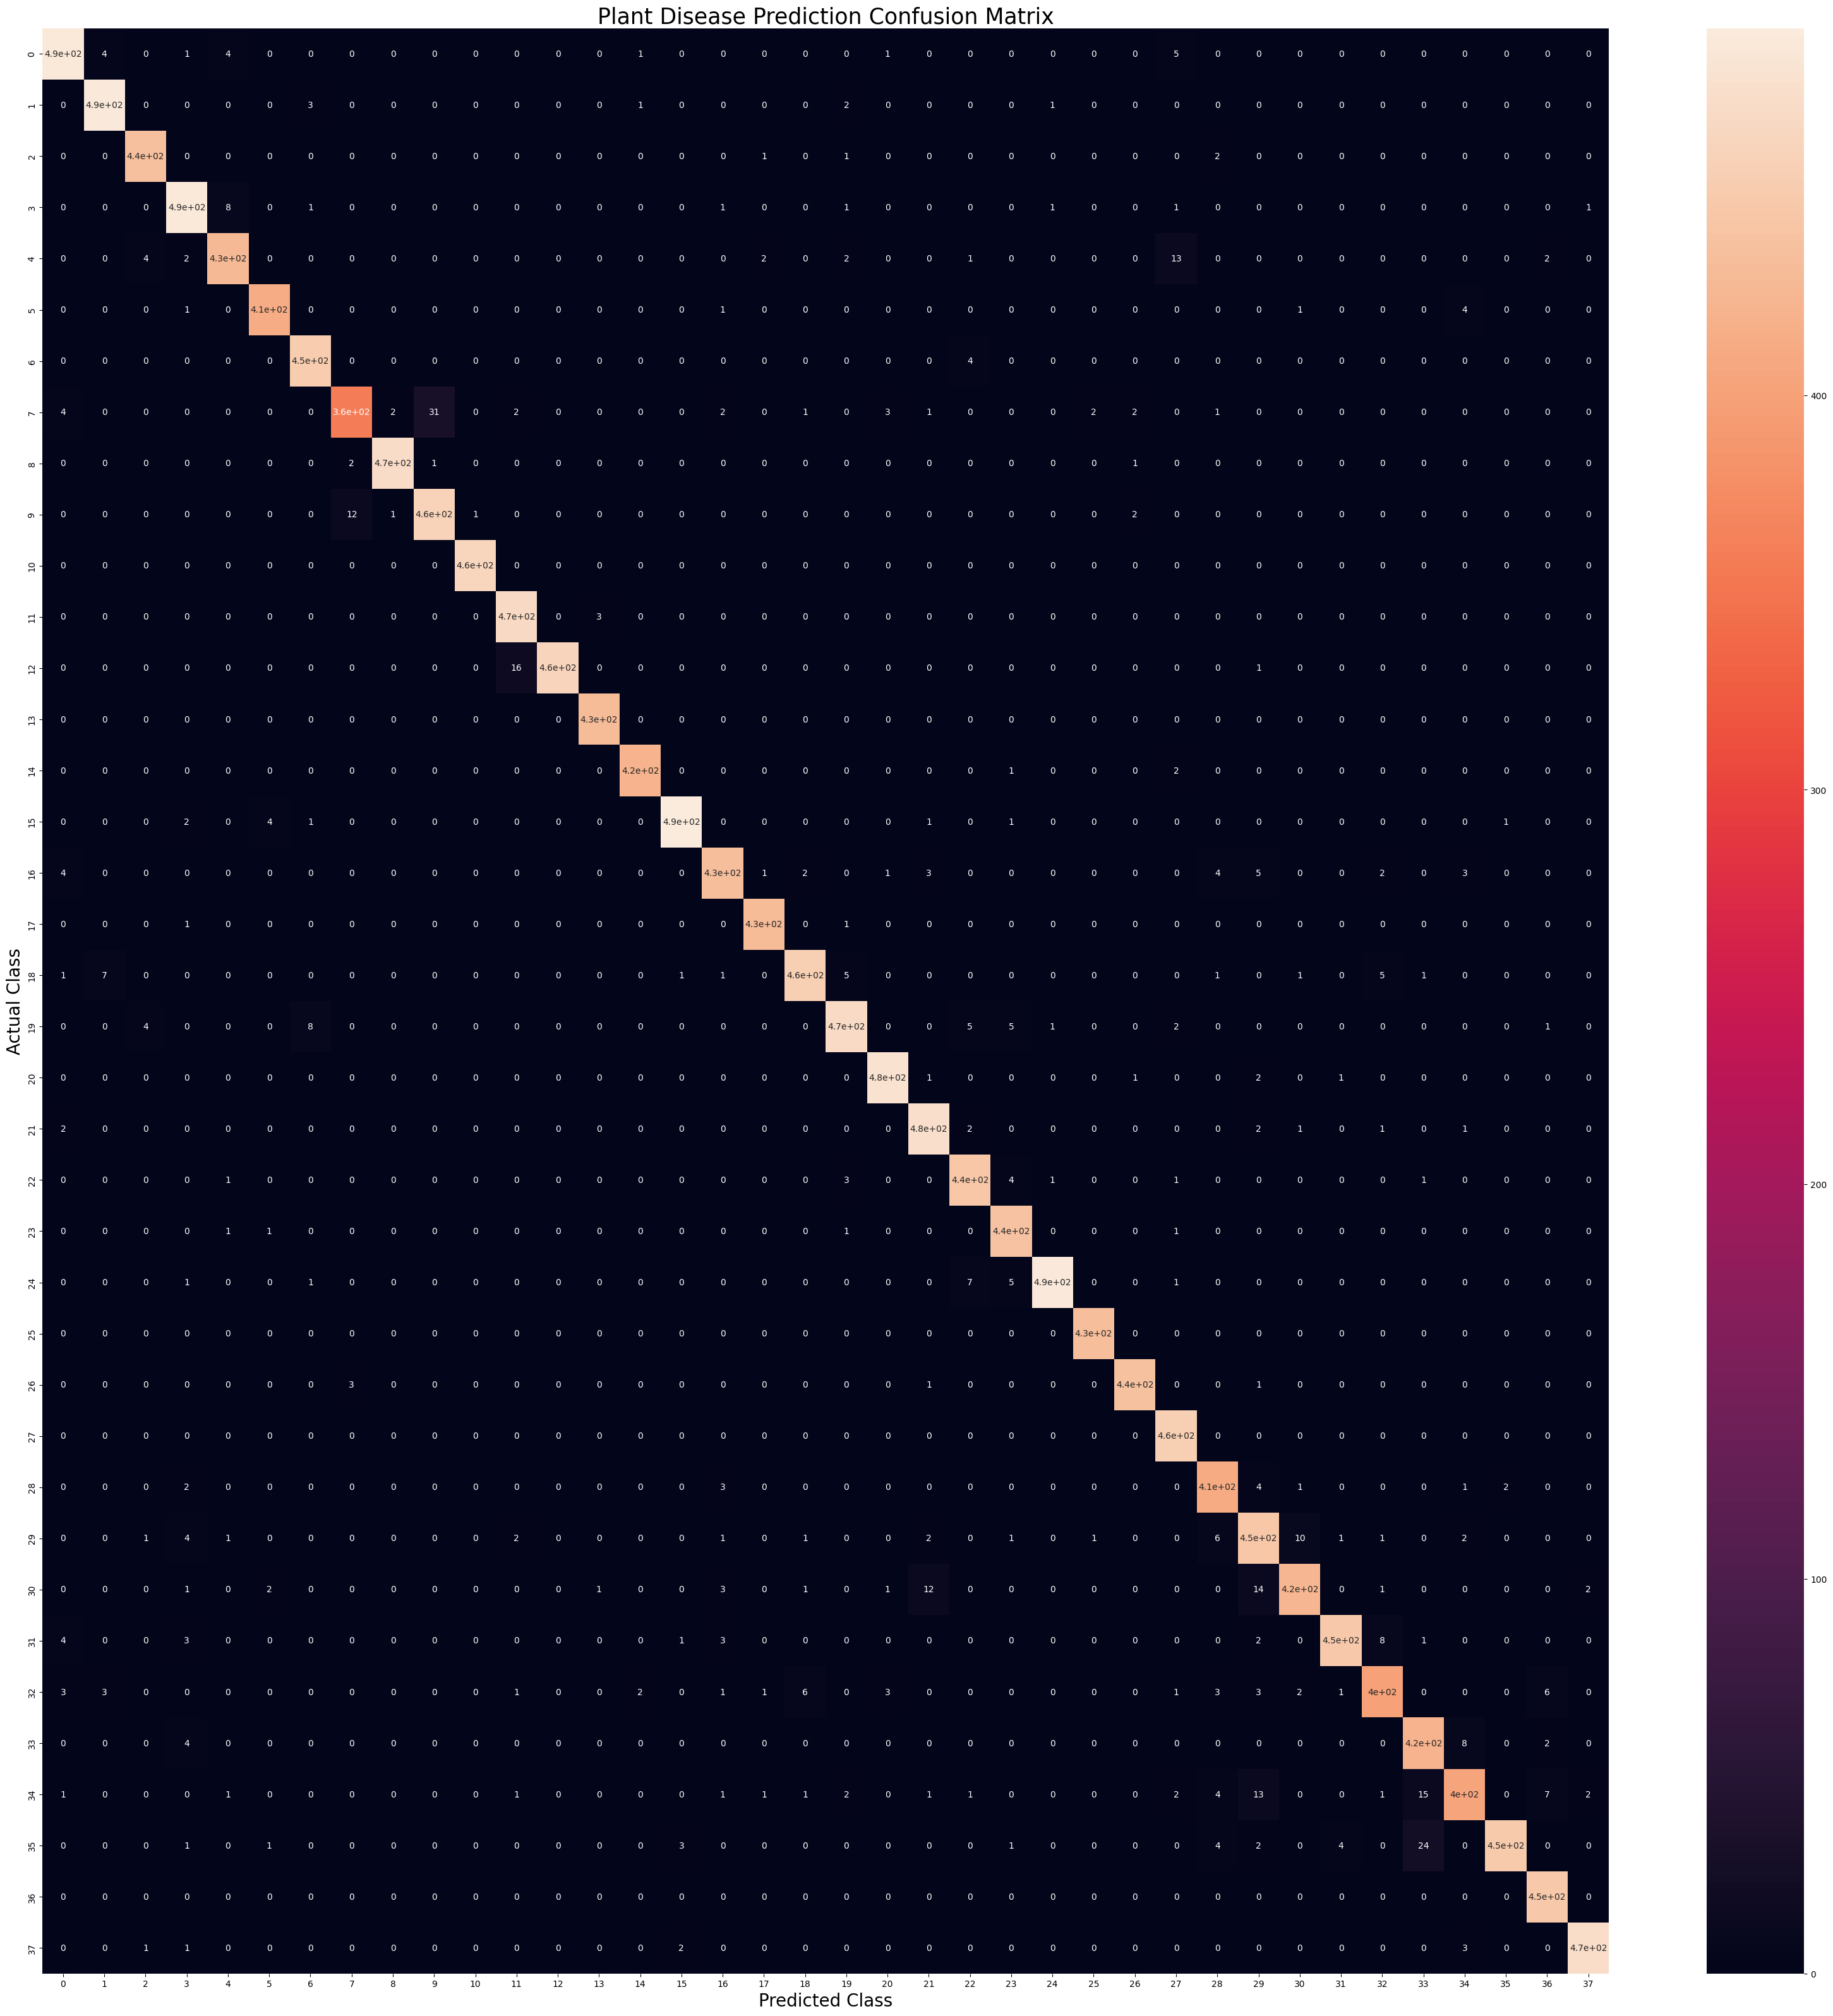

In [92]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()

In [93]:
import json

class_names = list(validation_set.class_indices.keys())

with open("class_names.json", "w") as f:
    json.dump(class_names, f)